# Facebook Ads: Media Type and Demographic Targeting Analysis

This notebook focuses specifically on:
- **wmp_media_type**: Type of media (video, image, text)
- **demographic_distribution**: Demographic targeting data (age, gender)

## Analysis Goals
1. How many ads have demographic_distribution data
2. Which ads have age targeting in demographic_distribution
3. Which ads have race targeting (from race_of_focus)
4. Overlap: Which media types (video/image/text) have age/race targeting


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from collections import Counter

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load the Facebook variables dataset (core dataset)
data_path = '../../data/facebook/fb_2022_adid_var_040825.csv'
df = pd.read_csv(data_path, low_memory=False)

print("=" * 80)
print("DATASET LOADING")
print("=" * 80)
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Columns: {len(df.columns)}")
print(f"Rows: {len(df):,}")

# Check for our focus columns
print(f"\nFocus columns:")
print(f"  wmp_media_type: {'✓ Found' if 'wmp_media_type' in df.columns else '✗ Not found'}")
print(f"  demographic_distribution: {'✓ Found' if 'demographic_distribution' in df.columns else '✗ Not found'}")
print(f"  race_of_focus: {'✓ Found' if 'race_of_focus' in df.columns else '✗ Not found'}")


DATASET LOADING
Dataset shape: (377721, 55)
Memory usage: 1557.36 MB
Columns: 55
Rows: 377,721

Focus columns:
  wmp_media_type: ✓ Found
  demographic_distribution: ✓ Found
  race_of_focus: ✓ Found


In [ ]:
# SAMPLE ROWS: View how demographic_distribution is filled
print("=" * 80)
print("SAMPLE ROWS: Demographic Distribution Data")
print("=" * 80)

# Show sample rows with demographic_distribution
sample_cols = ['ad_id', 'wmp_media_type', 'demographic_distribution', 'race_of_focus']
available_cols = [col for col in sample_cols if col in df.columns]

print(f"\nShowing 5 sample rows with demographic_distribution data:")
print(f"Columns displayed: {', '.join(available_cols)}\n")

# Get rows that have demographic_distribution data
if 'demographic_distribution' in df.columns:
    has_demo = df['demographic_distribution'].notna() & (df['demographic_distribution'].astype(str).str.strip() != '')
    if has_demo.sum() > 0:
        sample_df = df[has_demo][available_cols].head(5)
        
        # Set display options to show full content
        pd.set_option('display.max_colwidth', None)
        
        for idx, (row_idx, row) in enumerate(sample_df.iterrows(), 1):
            print(f"\n{'='*100}")
            print(f"SAMPLE ROW {idx} (Index: {row_idx})")
            print(f"{'='*100}")
            for col in available_cols:
                value = row[col]
                if pd.isna(value):
                    print(f"{col:30s}: <NaN>")
                elif col == 'demographic_distribution':
                    # Show full demographic_distribution
                    print(f"{col:30s}: {str(value)}")
                else:
                    print(f"{col:30s}: {str(value)}")
        
        # Reset display option
        pd.set_option('display.max_colwidth', 100)
    else:
        print("\n⚠️  No rows found with demographic_distribution data")
        
    # Also show a few rows without demographic_distribution for comparison
    print(f"\n\n{'='*100}")
    print("COMPARISON: 3 rows WITHOUT demographic_distribution")
    print(f"{'='*100}")
    
    no_demo = ~has_demo
    if no_demo.sum() > 0:
        sample_no_demo = df[no_demo][available_cols].head(3)
        pd.set_option('display.max_colwidth', None)
        
        for idx, (row_idx, row) in enumerate(sample_no_demo.iterrows(), 1):
            print(f"\n--- Row {idx} (Index: {row_idx}) ---")
            for col in available_cols:
                value = row[col]
                if pd.isna(value):
                    print(f"{col:30s}: <NaN>")
                else:
                    print(f"{col:30s}: {str(value)}")
        
        pd.set_option('display.max_colwidth', 100)
else:
    print("⚠️  'demographic_distribution' column not found")


DEMOGRAPHIC DISTRIBUTION ANALYSIS

Total ads: 377,721
Missing demographic_distribution: 41,483 (11.0%)
Empty demographic_distribution: 0 (0.0%)
Has demographic_distribution: 336,238 (89.0%)

Parsing demographic_distribution...

Ads with age target in demographic_distribution: 336,238 (89.0%)

Age ranges found in demographic_distribution:
  35-44          : 321,611 ads ( 95.6%)
  45-54          : 316,861 ads ( 94.2%)
  55-64          : 315,479 ads ( 93.8%)
  25-34          : 313,528 ads ( 93.2%)
  65+            : 309,439 ads ( 92.0%)
  18-24          : 281,925 ads ( 83.8%)
  13-17          : 70,298 ads ( 20.9%)
  All (Automated App Ads):     13 ads (  0.0%)
  Unknown        :      2 ads (  0.0%)


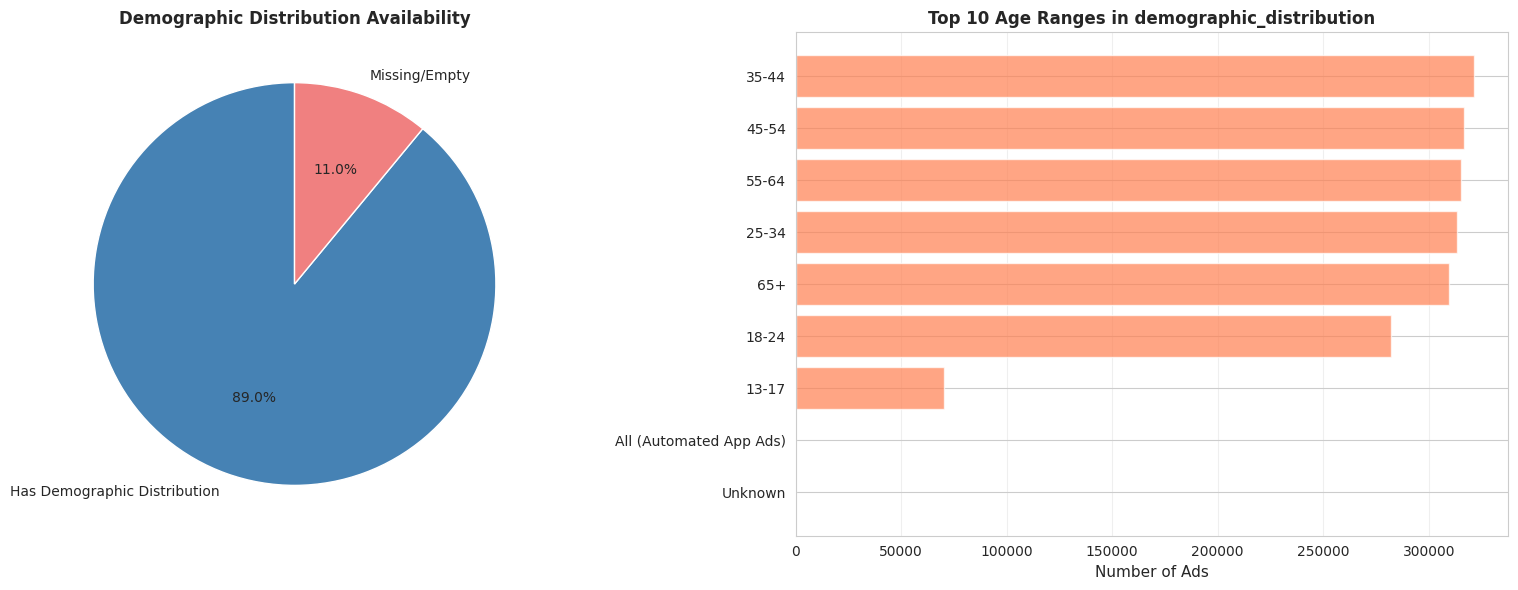

In [3]:
# DEMOGRAPHIC DISTRIBUTION ANALYSIS
print("=" * 80)
print("DEMOGRAPHIC DISTRIBUTION ANALYSIS")
print("=" * 80)

if 'demographic_distribution' in df.columns:
    total_ads = len(df)
    
    # Check missing/empty
    missing_demo = df['demographic_distribution'].isna().sum()
    empty_demo = (df['demographic_distribution'].astype(str).str.strip() == '').sum()
    has_demo = df['demographic_distribution'].notna() & (df['demographic_distribution'].astype(str).str.strip() != '')
    has_demo_count = has_demo.sum()
    
    print(f"\nTotal ads: {total_ads:,}")
    print(f"Missing demographic_distribution: {missing_demo:,} ({missing_demo/total_ads*100:.1f}%)")
    print(f"Empty demographic_distribution: {empty_demo:,} ({empty_demo/total_ads*100:.1f}%)")
    print(f"Has demographic_distribution: {has_demo_count:,} ({has_demo_count/total_ads*100:.1f}%)")
    
    # Helper function to parse demographic distribution
    def parse_demographic_distribution_detailed(value):
        """Extract detailed demographic info from JSON format"""
        if pd.isna(value):
            return {'has_data': False, 'ages': [], 'genders': [], 'has_age': False}
        
        try:
            if isinstance(value, str):
                data = json.loads(value)
                ages = set()
                genders = set()
                has_age = False
                
                for item in data:
                    age = item.get('age', '')
                    gender = item.get('gender', '')
                    
                    if age and age.strip() != '':
                        ages.add(age.strip())
                        has_age = True
                    
                    if gender and gender.strip() != '':
                        genders.add(gender.strip())
                
                return {
                    'has_data': True,
                    'ages': list(ages),
                    'genders': list(genders),
                    'has_age': has_age,
                    'age_count': len(ages),
                    'gender_count': len(genders)
                }
        except:
            pass
        
        return {'has_data': False, 'ages': [], 'genders': [], 'has_age': False, 'age_count': 0, 'gender_count': 0}
    
    # Parse demographic distribution
    print("\nParsing demographic_distribution...")
    demo_parsed = df['demographic_distribution'].apply(parse_demographic_distribution_detailed)
    demo_df = pd.DataFrame(list(demo_parsed))
    
    # Add flags
    df['has_demographic_dist'] = demo_df['has_data']
    df['has_age_target'] = demo_df['has_age']
    df['age_target_count'] = demo_df['age_count']
    
    # Summary
    has_age_count = df['has_age_target'].sum()
    print(f"\nAds with age target in demographic_distribution: {has_age_count:,} ({has_age_count/total_ads*100:.1f}%)")
    
    # Analyze age ranges
    if has_age_count > 0:
        all_ages = []
        for ages_list in demo_df[demo_df['has_age']]['ages']:
            all_ages.extend(ages_list)
        age_counts = Counter(all_ages)
        
        print(f"\nAge ranges found in demographic_distribution:")
        for age, count in age_counts.most_common():
            pct = (count / has_age_count) * 100
            print(f"  {age:15s}: {count:6,} ads ({pct:5.1f}%)")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Availability
    availability = [has_demo_count, missing_demo + empty_demo]
    labels = ['Has Demographic Distribution', 'Missing/Empty']
    colors = ['steelblue', 'lightcoral']
    axes[0].pie(availability, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    axes[0].set_title('Demographic Distribution Availability', fontsize=12, fontweight='bold')
    
    # Age ranges
    if has_age_count > 0:
        top_ages = dict(age_counts.most_common(10))
        axes[1].barh(list(top_ages.keys()), list(top_ages.values()), color='coral', alpha=0.7)
        axes[1].set_xlabel('Number of Ads', fontsize=11)
        axes[1].set_title('Top 10 Age Ranges in demographic_distribution', fontsize=12, fontweight='bold')
        axes[1].invert_yaxis()
        axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  'demographic_distribution' column not found")


RACE TARGETING ANALYSIS

Total ads: 377,721
Missing race_of_focus: 0 (0.0%)
'No race of focus': 225,240 (59.6%)
Has race targeting: 152,481 (40.4%)

Race of focus distribution:
  Downballot                    : 57,849 ads ( 15.3%)
  PAS0                          :  4,367 ads (  1.2%)
  GAS0                          :  3,268 ads (  0.9%)
  NY14                          :  3,036 ads (  0.8%)
  NVS0                          :  2,712 ads (  0.7%)
  CA47                          :  2,123 ads (  0.6%)
  FLS0                          :  2,012 ads (  0.5%)
  AZS0                          :  1,995 ads (  0.5%)
  WI01                          :  1,890 ads (  0.5%)
  WIS0                          :  1,885 ads (  0.5%)
  COS0                          :  1,773 ads (  0.5%)
  OHS0                          :  1,633 ads (  0.4%)
  NCS0                          :  1,375 ads (  0.4%)
  NC14                          :  1,041 ads (  0.3%)
  NH01                          :    935 ads (  0.2%)


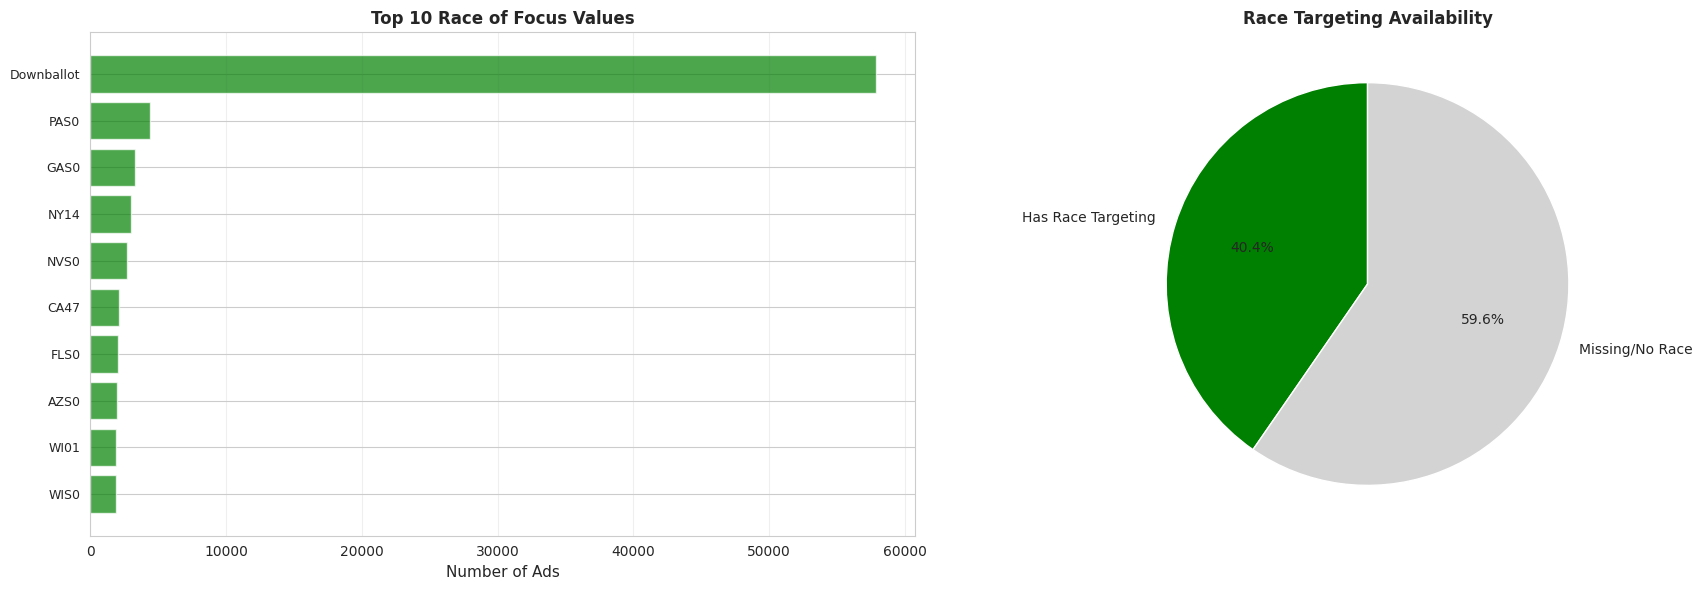

In [8]:
# RACE TARGETING ANALYSIS
print("=" * 80)
print("RACE TARGETING ANALYSIS")
print("=" * 80)

if 'race_of_focus' in df.columns:
    total_ads = len(df)
    
    # Check missing/empty
    missing_race = df['race_of_focus'].isna().sum()
    empty_race = (df['race_of_focus'].astype(str).str.strip() == '')
    no_race = (df['race_of_focus'].astype(str).str.strip() == 'No race of focus')
    has_race = df['race_of_focus'].notna() & ~empty_race & ~no_race
    has_race_count = has_race.sum()
    
    print(f"\nTotal ads: {total_ads:,}")
    print(f"Missing race_of_focus: {missing_race:,} ({missing_race/total_ads*100:.1f}%)")
    print(f"'No race of focus': {no_race.sum():,} ({no_race.sum()/total_ads*100:.1f}%)")
    print(f"Has race targeting: {has_race_count:,} ({has_race_count/total_ads*100:.1f}%)")
    
    # Add flag
    df['has_race_target'] = has_race
    
    # Analyze race values
    if has_race_count > 0:
        race_counts = df[has_race]['race_of_focus'].value_counts()
        print(f"\nRace of focus distribution:")
        for race, count in race_counts.head(15).items():
            pct = (count / total_ads) * 100
            print(f"  {str(race):30s}: {count:6,} ads ({pct:5.1f}%)")
        
        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        
        # Top races
        top_races = race_counts.head(10)
        axes[0].barh(range(len(top_races)), top_races.values, color='green', alpha=0.7)
        axes[0].set_yticks(range(len(top_races)))
        axes[0].set_yticklabels(top_races.index, fontsize=9)
        axes[0].set_xlabel('Number of Ads', fontsize=11)
        axes[0].set_title('Top 10 Race of Focus Values', fontsize=12, fontweight='bold')
        axes[0].invert_yaxis()
        axes[0].grid(True, alpha=0.3, axis='x')
        
        # Availability
        availability = [has_race_count, missing_race + no_race.sum()]
        labels = ['Has Race Targeting', 'Missing/No Race']
        colors = ['green', 'lightgray']
        axes[1].pie(availability, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
        axes[1].set_title('Race Targeting Availability', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    else:
        print("\n⚠️  No race targeting data found")
else:
    print("⚠️  'race_of_focus' column not found")
    df['has_race_target'] = False


MEDIA TYPE ANALYSIS

Total ads: 377,721
Missing wmp_media_type: 3,024 (0.8%)

Media type distribution:
  image               : 241,963 ads ( 64.1%)
  video               : 116,111 ads ( 30.7%)
  image, video        : 16,623 ads (  4.4%)


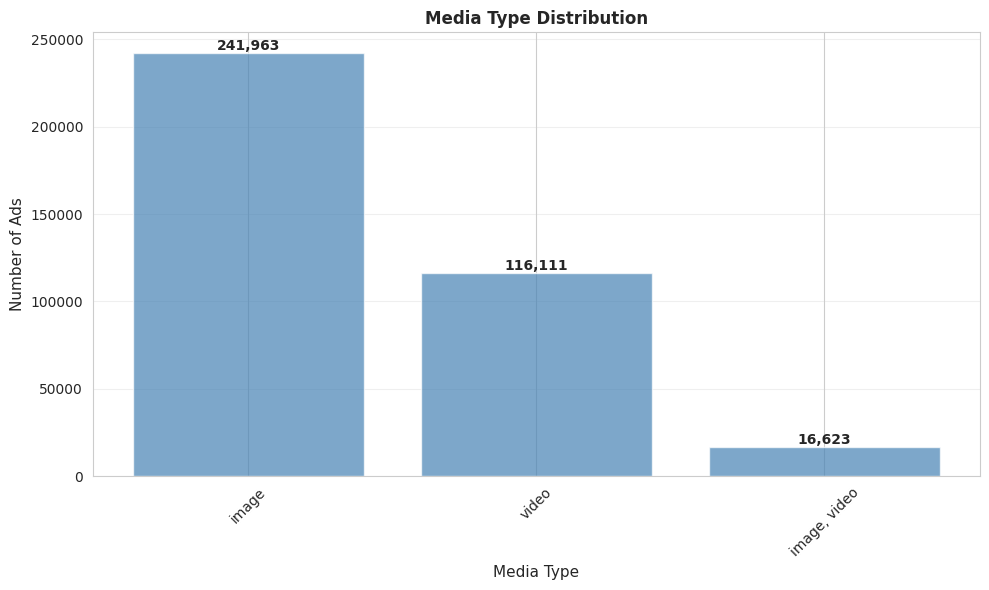

In [9]:
# MEDIA TYPE ANALYSIS
print("=" * 80)
print("MEDIA TYPE ANALYSIS")
print("=" * 80)

if 'wmp_media_type' in df.columns:
    total_ads = len(df)
    
    # Media type distribution
    media_type_counts = df['wmp_media_type'].value_counts()
    missing_media = df['wmp_media_type'].isna().sum()
    
    print(f"\nTotal ads: {total_ads:,}")
    print(f"Missing wmp_media_type: {missing_media:,} ({missing_media/total_ads*100:.1f}%)")
    print(f"\nMedia type distribution:")
    for media_type, count in media_type_counts.items():
        pct = (count / total_ads) * 100
        print(f"  {str(media_type):20s}: {count:6,} ads ({pct:5.1f}%)")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(media_type_counts.index.astype(str), media_type_counts.values, color='steelblue', alpha=0.7)
    ax.set_xlabel('Media Type', fontsize=11)
    ax.set_ylabel('Number of Ads', fontsize=11)
    ax.set_title('Media Type Distribution', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(media_type_counts.values):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  'wmp_media_type' column not found")


OVERLAP ANALYSIS: Age/Race Targeting vs Media Type

Summary:
  Total ads: 377,721
  Has age target: 336,238 (89.0%)
  Has race target: 152,481 (40.4%)
  Has age OR race target: 350,459 (92.8%)
  Has age AND race target: 138,260 (36.6%)

Ads with age OR race targeting: 350,459

Media Type Distribution for Ads with Age/Race Targeting:
  image               : 223,669 ( 63.8%)
  video               : 108,207 ( 30.9%)
  image, video        : 15,789 (  4.5%)

DETAILED BREAKDOWN: Targeting Type vs Media Type

Breakdown by Media Type:
  Media_Type  Total_Ads  Has_Age_Target  Has_Age_Target_Pct  Has_Race_Target  Has_Race_Target_Pct  Has_Age_OR_Race  Has_Age_OR_Race_Pct  Has_Age_AND_Race
       image     241963          214114           88.490389            91713            37.903729           223669            92.439340             82158
       video     116111          104069           89.628890            52841            45.509039           108207            93.192721             48703
image

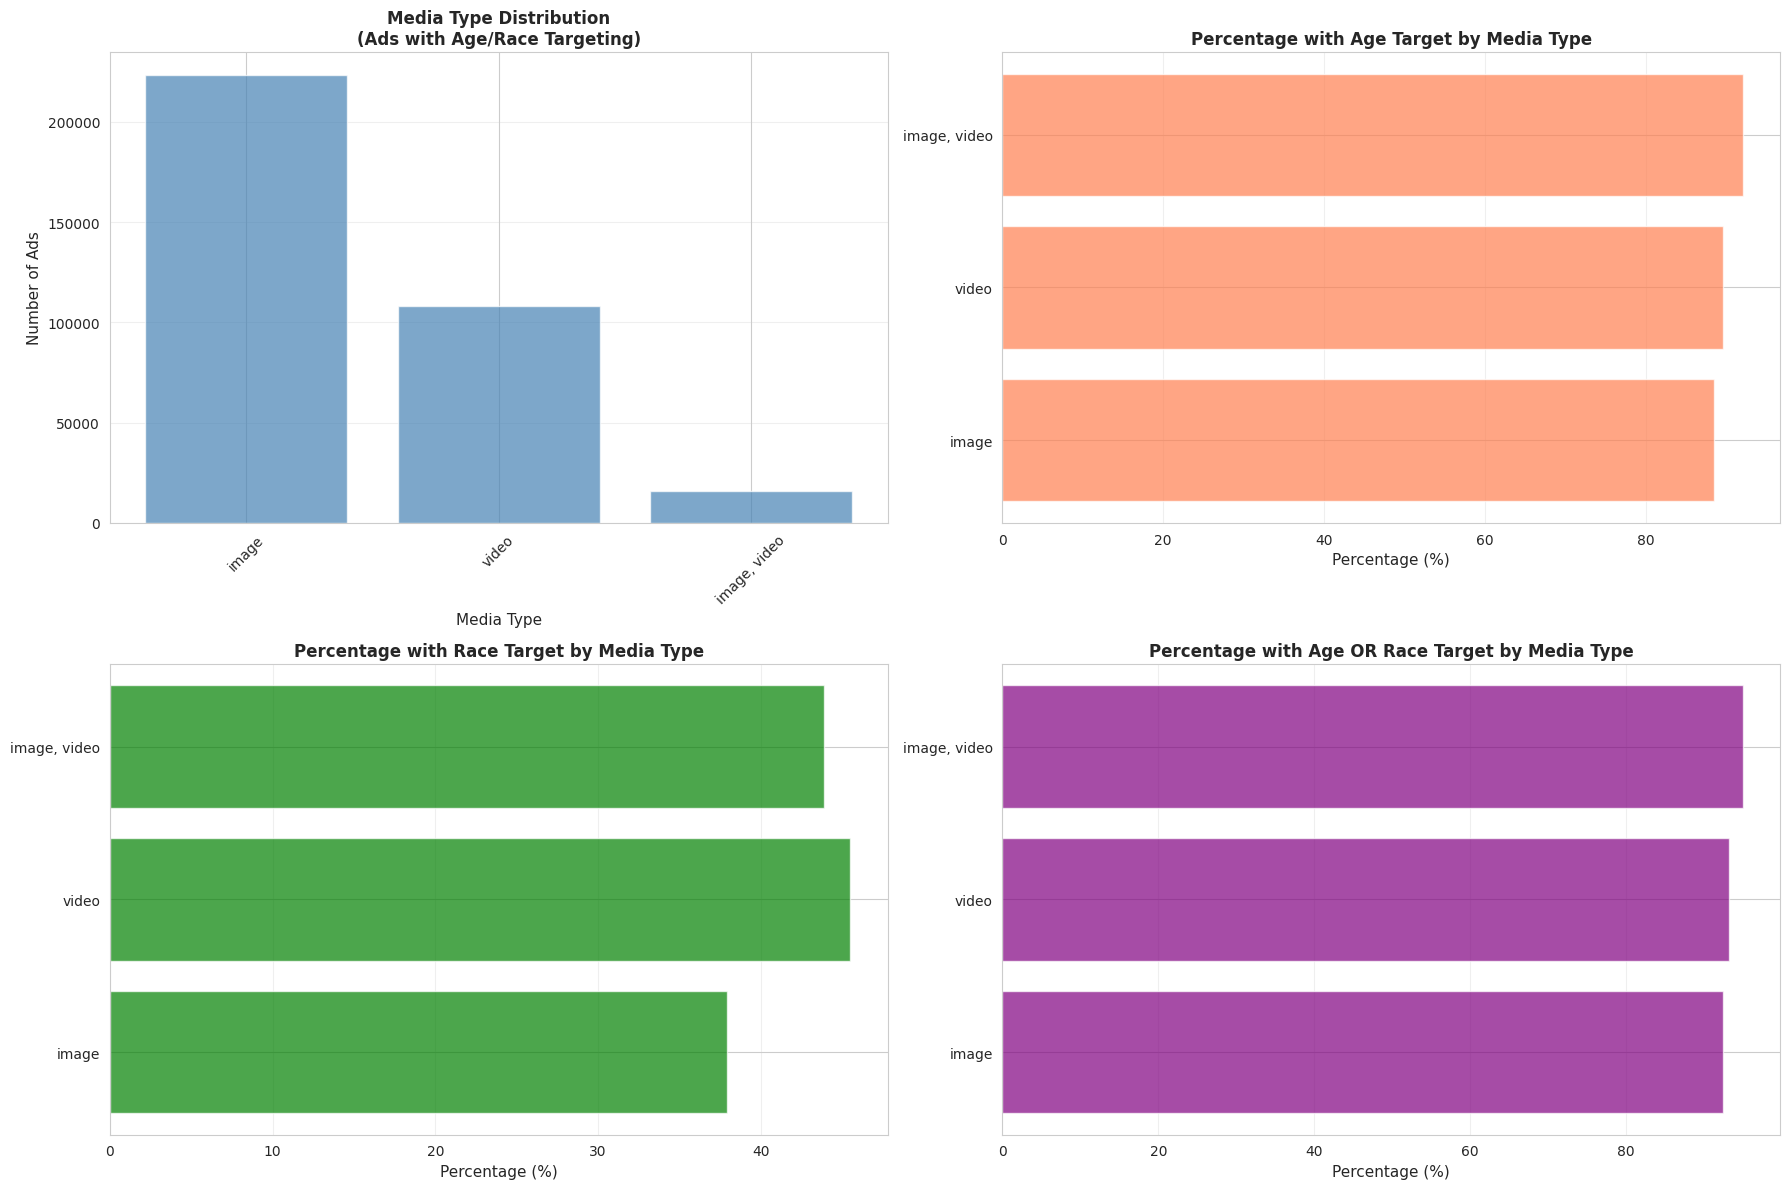


CROSS-TABULATION: Media Type vs Targeting Type

Cross-tabulation (counts):
targeting_type  Age + Race  Age Only   None  Race Only     All
wmp_media_type                                                
image                82158    131956  18294       9555  241963
image, video          6811      8493    834        485   16623
video                48703     55366   7904       4138  116111
All                 137672    195815  27032      14178  374697

Cross-tabulation (percentages by row):
targeting_type  Age + Race  Age Only  None  Race Only
wmp_media_type                                       
image                 34.0      54.5   7.6        3.9
image, video          41.0      51.1   5.0        2.9
video                 41.9      47.7   6.8        3.6


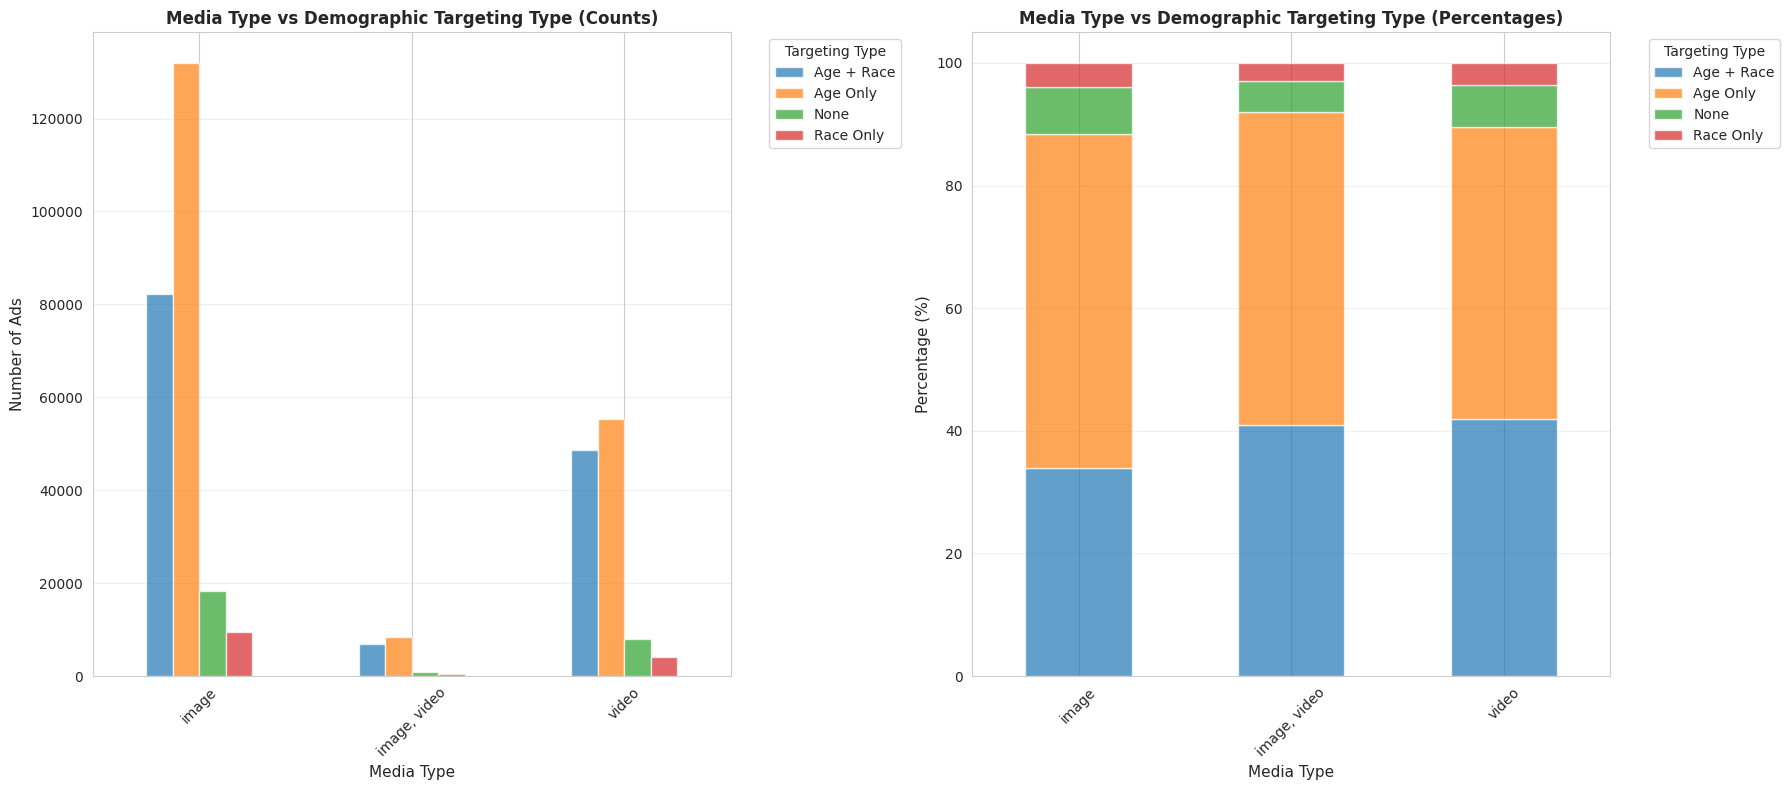

In [10]:
# OVERLAP ANALYSIS: Age/Race Targeting vs Media Type
print("=" * 80)
print("OVERLAP ANALYSIS: Age/Race Targeting vs Media Type")
print("=" * 80)

if 'wmp_media_type' in df.columns:
    total_ads = len(df)
    
    # Calculate targeting flags
    has_age_or_race = (df['has_age_target'] | df['has_race_target']).sum()
    has_age_and_race = (df['has_age_target'] & df['has_race_target']).sum()
    
    print(f"\nSummary:")
    print(f"  Total ads: {total_ads:,}")
    print(f"  Has age target: {df['has_age_target'].sum():,} ({df['has_age_target'].sum()/total_ads*100:.1f}%)")
    print(f"  Has race target: {df['has_race_target'].sum():,} ({df['has_race_target'].sum()/total_ads*100:.1f}%)")
    print(f"  Has age OR race target: {has_age_or_race:,} ({has_age_or_race/total_ads*100:.1f}%)")
    print(f"  Has age AND race target: {has_age_and_race:,} ({has_age_and_race/total_ads*100:.1f}%)")
    
    # Filter to ads with age or race targeting
    ads_with_targeting = df[df['has_age_target'] | df['has_race_target']].copy()
    
    print(f"\nAds with age OR race targeting: {len(ads_with_targeting):,}")
    
    if len(ads_with_targeting) > 0:
        # Media type distribution for ads with targeting
        media_type_counts = ads_with_targeting['wmp_media_type'].value_counts()
        
        print(f"\nMedia Type Distribution for Ads with Age/Race Targeting:")
        for media_type, count in media_type_counts.items():
            pct = (count / len(ads_with_targeting)) * 100
            print(f"  {str(media_type):20s}: {count:6,} ({pct:5.1f}%)")
        
        # Detailed breakdown by media type
        print(f"\n" + "=" * 80)
        print("DETAILED BREAKDOWN: Targeting Type vs Media Type")
        print("=" * 80)
        
        breakdown_data = []
        
        for media_type in df['wmp_media_type'].dropna().unique():
            media_df = df[df['wmp_media_type'] == media_type]
            total_media = len(media_df)
            
            has_age = (media_df['has_age_target']).sum()
            has_race = (media_df['has_race_target']).sum()
            has_age_or_race = (media_df['has_age_target'] | media_df['has_race_target']).sum()
            has_age_and_race = (media_df['has_age_target'] & media_df['has_race_target']).sum()
            
            breakdown_data.append({
                'Media_Type': media_type,
                'Total_Ads': total_media,
                'Has_Age_Target': has_age,
                'Has_Age_Target_Pct': (has_age / total_media * 100) if total_media > 0 else 0,
                'Has_Race_Target': has_race,
                'Has_Race_Target_Pct': (has_race / total_media * 100) if total_media > 0 else 0,
                'Has_Age_OR_Race': has_age_or_race,
                'Has_Age_OR_Race_Pct': (has_age_or_race / total_media * 100) if total_media > 0 else 0,
                'Has_Age_AND_Race': has_age_and_race
            })
        
        breakdown_df = pd.DataFrame(breakdown_data)
        breakdown_df = breakdown_df.sort_values('Total_Ads', ascending=False)
        
        print("\nBreakdown by Media Type:")
        print(breakdown_df.to_string(index=False))
        
        # Visualize
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        
        # 1. Media type distribution for ads with targeting
        axes[0, 0].bar(media_type_counts.index.astype(str), media_type_counts.values, color='steelblue', alpha=0.7)
        axes[0, 0].set_xlabel('Media Type', fontsize=11)
        axes[0, 0].set_ylabel('Number of Ads', fontsize=11)
        axes[0, 0].set_title('Media Type Distribution\n(Ads with Age/Race Targeting)', fontsize=12, fontweight='bold')
        axes[0, 0].tick_params(axis='x', rotation=45)
        axes[0, 0].grid(True, alpha=0.3, axis='y')
        
        # 2. Percentage with age target by media type
        axes[0, 1].barh(breakdown_df['Media_Type'], breakdown_df['Has_Age_Target_Pct'], color='coral', alpha=0.7)
        axes[0, 1].set_xlabel('Percentage (%)', fontsize=11)
        axes[0, 1].set_title('Percentage with Age Target by Media Type', fontsize=12, fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3, axis='x')
        
        # 3. Percentage with race target by media type
        axes[1, 0].barh(breakdown_df['Media_Type'], breakdown_df['Has_Race_Target_Pct'], color='green', alpha=0.7)
        axes[1, 0].set_xlabel('Percentage (%)', fontsize=11)
        axes[1, 0].set_title('Percentage with Race Target by Media Type', fontsize=12, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3, axis='x')
        
        # 4. Percentage with age OR race by media type
        axes[1, 1].barh(breakdown_df['Media_Type'], breakdown_df['Has_Age_OR_Race_Pct'], color='purple', alpha=0.7)
        axes[1, 1].set_xlabel('Percentage (%)', fontsize=11)
        axes[1, 1].set_title('Percentage with Age OR Race Target by Media Type', fontsize=12, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.show()
        
        # Cross-tabulation
        print(f"\n" + "=" * 80)
        print("CROSS-TABULATION: Media Type vs Targeting Type")
        print("=" * 80)
        
        # Create targeting type categories
        df['targeting_type'] = 'None'
        df.loc[df['has_age_target'] & ~df['has_race_target'], 'targeting_type'] = 'Age Only'
        df.loc[~df['has_age_target'] & df['has_race_target'], 'targeting_type'] = 'Race Only'
        df.loc[df['has_age_target'] & df['has_race_target'], 'targeting_type'] = 'Age + Race'
        
        crosstab = pd.crosstab(df['wmp_media_type'], df['targeting_type'], margins=True)
        print("\nCross-tabulation (counts):")
        print(crosstab)
        
        # Percentage cross-tab
        crosstab_pct = pd.crosstab(df['wmp_media_type'], df['targeting_type'], normalize='index') * 100
        print("\nCross-tabulation (percentages by row):")
        print(crosstab_pct.round(1))
        
        # Visualize cross-tab
        fig, axes = plt.subplots(1, 2, figsize=(18, 8))
        
        # Counts
        crosstab_plot = pd.crosstab(df['wmp_media_type'], df['targeting_type'])
        crosstab_plot.plot(kind='bar', ax=axes[0], alpha=0.7)
        axes[0].set_xlabel('Media Type', fontsize=11)
        axes[0].set_ylabel('Number of Ads', fontsize=11)
        axes[0].set_title('Media Type vs Demographic Targeting Type (Counts)', fontsize=12, fontweight='bold')
        axes[0].legend(title='Targeting Type', bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].grid(True, alpha=0.3, axis='y')
        
        # Percentages
        crosstab_pct.plot(kind='bar', ax=axes[1], alpha=0.7, stacked=True)
        axes[1].set_xlabel('Media Type', fontsize=11)
        axes[1].set_ylabel('Percentage (%)', fontsize=11)
        axes[1].set_title('Media Type vs Demographic Targeting Type (Percentages)', fontsize=12, fontweight='bold')
        axes[1].legend(title='Targeting Type', bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
    else:
        print("\n⚠️  No ads found with age or race targeting")
else:
    print("⚠️  'wmp_media_type' column not found")


In [11]:
# SUMMARY AND ASSESSMENT
print("=" * 80)
print("SUMMARY AND ASSESSMENT")
print("=" * 80)

total_ads = len(df)

print(f"\n📊 KEY STATISTICS:")
print(f"  Total ads: {total_ads:,}")
print(f"  Has demographic_distribution: {df['has_demographic_dist'].sum():,} ({df['has_demographic_dist'].sum()/total_ads*100:.1f}%)")
print(f"  Has age target: {df['has_age_target'].sum():,} ({df['has_age_target'].sum()/total_ads*100:.1f}%)")
print(f"  Has race target: {df['has_race_target'].sum():,} ({df['has_race_target'].sum()/total_ads*100:.1f}%)")
print(f"  Has age OR race: {(df['has_age_target'] | df['has_race_target']).sum():,} ({(df['has_age_target'] | df['has_race_target']).sum()/total_ads*100:.1f}%)")

if 'wmp_media_type' in df.columns:
    print(f"\n📺 BY MEDIA TYPE:")
    for media_type in df['wmp_media_type'].dropna().unique():
        media_df = df[df['wmp_media_type'] == media_type]
        with_targeting = (media_df['has_age_target'] | media_df['has_race_target']).sum()
        print(f"  {str(media_type):15s}: {len(media_df):6,} total, {with_targeting:6,} with age/race targeting ({with_targeting/len(media_df)*100:.1f}%)")

print(f"\n✅ This analysis shows:")
print(f"  1. How many ads have demographic targeting data")
print(f"  2. Which ads specifically target by age (from demographic_distribution)")
print(f"  3. Which ads specifically target by race (from race_of_focus)")
print(f"  4. How demographic targeting overlaps with media types (video/image/text)")


SUMMARY AND ASSESSMENT

📊 KEY STATISTICS:
  Total ads: 377,721
  Has demographic_distribution: 336,238 (89.0%)
  Has age target: 336,238 (89.0%)
  Has race target: 152,481 (40.4%)
  Has age OR race: 350,459 (92.8%)

📺 BY MEDIA TYPE:
  image          : 241,963 total, 223,669 with age/race targeting (92.4%)
  video          : 116,111 total, 108,207 with age/race targeting (93.2%)
  image, video   : 16,623 total, 15,789 with age/race targeting (95.0%)

✅ This analysis shows:
  1. How many ads have demographic targeting data
  2. Which ads specifically target by age (from demographic_distribution)
  3. Which ads specifically target by race (from race_of_focus)
  4. How demographic targeting overlaps with media types (video/image/text)
